<a href="https://colab.research.google.com/github/juss7501/PriceChecker/blob/main/adaline_ex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install mlxtend --upgrade

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

In [13]:
class Adaline(object):

    def __init__(self, eta=0.01, epochs=50):
        self.eta = eta
        self.epochs = epochs

    def linear_combination(self, X):
        #YOUR CODE GOES HERE
        #return w0 + w1x1 + w2x2 + ⋯ + wnxn
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def predict(self, X):
        # use step function for thresholding
        #YOUR CODE GOES HERE
        return np.where(self.linear_combination(X) >= 0.0, 1, -1)

    def train(self, X, y):
        # X is the input data matrix
        # y is the output vector corresponding to input X
        self.w_ = np.zeros(X.shape[1] + 1) # hide the bias in the weight vector
        self.cost_ = []

        for _ in range(self.epochs):
            #YOUR CODE GOES HERE
            # output
            y_pred = self.linear_combination(X)
            # errors
            err = y - y_pred
            #  update weights
            #  bias
            self.w_[0] += self.eta * err.sum()
            #  other weights
            self.w_[1:] += self.eta * X.T.dot(err)
            #  cost (1/2 SSE)
            cost = 0.5 * (err**2).sum()
            self.cost_.append(cost)
        return self

In [14]:
# Load the Iris dataset into a dataframe
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data', header=None)
df.head

<bound method NDFrame.head of        0    1    2    3               4
0    5.1  3.5  1.4  0.2     Iris-setosa
1    4.9  3.0  1.4  0.2     Iris-setosa
2    4.7  3.2  1.3  0.2     Iris-setosa
3    4.6  3.1  1.5  0.2     Iris-setosa
4    5.0  3.6  1.4  0.2     Iris-setosa
..   ...  ...  ...  ...             ...
145  6.7  3.0  5.2  2.3  Iris-virginica
146  6.3  2.5  5.0  1.9  Iris-virginica
147  6.5  3.0  5.2  2.0  Iris-virginica
148  6.2  3.4  5.4  2.3  Iris-virginica
149  5.9  3.0  5.1  1.8  Iris-virginica

[150 rows x 5 columns]>

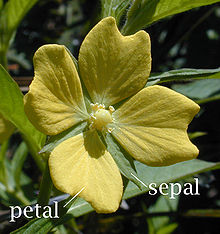

From English Wikipedia:

Image of a primrose willowherb Ludwigia octovalvis (family Onagraceae), flower showing petals and sepals. Photograph made in Hawai'i by Eric Guinther (Marshman at en.wikipedia) and released under the GNU Free Documentation License.

In [15]:
# Let's start with a linearly separable example
df = df.sample(frac = 1) # shuffle the data
y = df.iloc[0:100, 4].values
y = np.where(y == 'Iris-setosa', -1, 1)

# Consider the features sepal length and petal length
X = df.iloc[0:100, [0,2]].values

In [23]:
#Run adaline algorithm
#YOUR CODE GOES HERE
adal = Adaline(eta=0.001, epochs=50)
adal.train(X, y)

In [24]:
# Standardize features
X_std = np.copy(X)
X_std[:,0] = (X[:,0] - X[:,0].mean()) / X[:,0].std()
X_std[:,1] = (X[:,1] - X[:,1].mean()) / X[:,1].std()

In [34]:
adal = Adaline(epochs=500, eta=0.0001).train(X_std, y)

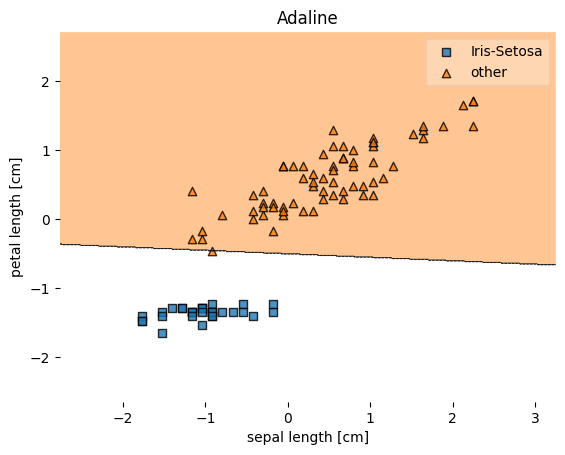

In [35]:
# Visualize binary classification regions
#YOUR CODE GOES HERE
ax = plot_decision_regions(X_std, y, clf=adal)
plt.title('Adaline')
plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles,
          ['Iris-Setosa', 'other',],
           framealpha=0.3, scatterpoints=1)
plt.show()

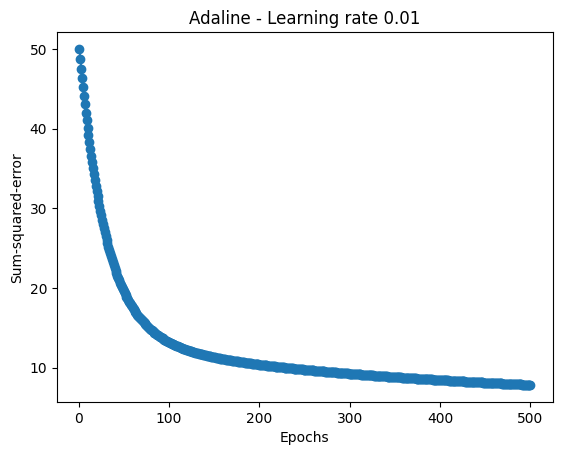

In [36]:
# Plot sum-of-squares error
#YOUR CODE GOES HERE
plt.plot(range(1, len(adal.cost_) + 1), adal.cost_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Sum-squared-error')
plt.title('Adaline - Learning rate 0.01')
plt.show()

In [37]:
# Test generalization
y_test = df.iloc[101:150, 4].values
y_test = np.where(y_test == 'Iris-setosa', -1, 1)

# Consider the features sepal length and petal length
X_test = df.iloc[101:150, [0,2]].values
X_test_std = np.copy(X_test)
X_test_std[:,0] = (X_test[:,0] - X_test[:,0].mean()) / X_test[:,0].std()
X_test_std[:,1] = (X_test[:,1] - X_test[:,1].mean()) / X_test[:,1].std()

In [38]:
yhat_test = adal.predict(X_test_std)
print(np.where(yhat_test-y_test == 0, 'ok', 'missclassified'))

['ok' 'ok' 'ok' 'ok' 'ok' 'ok' 'ok' 'ok' 'ok' 'ok' 'ok' 'ok' 'ok' 'ok'
 'ok' 'ok' 'ok' 'ok' 'ok' 'ok' 'ok' 'ok' 'ok' 'ok' 'ok' 'ok' 'ok' 'ok'
 'ok' 'ok' 'ok' 'ok' 'ok' 'ok' 'ok' 'ok' 'ok' 'ok' 'ok' 'ok' 'ok' 'ok'
 'ok' 'ok' 'ok' 'ok' 'ok' 'ok' 'ok']
